# Week 02. Tokens, N-Grams and Linguistics

## Text as Data
Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

Objective of the course: Build an LLM from scratch

Last lab we went over simple pandas pre-processing, some tokenization, sentiment analysis, etc (all over the place). Objective was to introduce packages, functions that are useful and need not much intuition.

Now we can start building a pipeline:

Where are we?

Stage 1.1) Data preparation and sampling

In [1]:
# set random seed
import numpy as np
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

import spacy
nlp = spacy.load('en_core_web_sm')

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import sent_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# For colab
#!pip install gensim
#!pip install tiktoken
#!pip install sentencepiece
# https://github.com/google/sentencepiece
#!pip install transformers


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# If you are using Google Colab, here's the code to load sc_cases_cleaned.pkl from local.
from google.colab import files
uploaded = files.upload()

In [2]:
# load cleaned data from lesson 1.
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df.columns

Index(['case_name', 'opinion_type', 'date_standard', 'authorship',
       'x_republican', 'maj_judges', 'dissent_judges', 'topic_id',
       'cite_count', 'opinion_text', 'year', 'log_cite_count'],
      dtype='object')

# Simple Pre-processing and Tokenization

Remember: **Pre-processing choices affect downstream results (Denny and Spirling 2017)**

*  Can you think of a case where removing whitespaces is detrimental?
*  Upper/lower cases?

Pre-processing decisions depend on our applications and its requirements. No general formula.

Here I do a lot of things for you to have the tools:

In [3]:
text = "Prof. Zurich hailed from Zurich. She got 3 M.A.'s from ETH."
 # Import all common punctuation
from string import punctuation
translator = str.maketrans(' ', ' ', punctuation)

# Import english stopwords
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    doc = doc.lower() # all lower case
    doc = doc.translate(translator) # remove punctuation
    doc = re.sub(r"(\d)([A-Za-z])", r"\1 \2", doc) # separate numbers from strings
    doc = re.sub(r"([A-Za-z])(\d)", r"\1 \2", doc) # separate strings from numbers
    words = doc.split() # split into tokens
    words = [w for w in words if w not in stoplist] # remove stopwords
    words = [w if not w.isdigit() else '#' for w in words] # normalize numbers
    return words

print(normalize_text(text))

['prof', 'zurich', 'hailed', 'zurich', 'got', '#', 'mas', 'eth']


**Stemming is different than Lemmatizing**

Stemming heuristically chops off word endings. Lemmatization reduces a word to its dictionary base form (lemma).

*When is stemming more useful than lemmatizing?*

In [4]:
word = 'studies'

# Stemming
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

# Lemmatizing
from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()

print('Stemmed word is:', stemmer.stem(word), 'and lemmatized word is:',
      wnl.lemmatize(word))

Stemmed word is: studi and lemmatized word is: study


**Sometimes better to use a Shortcut: `gensim.simple_preprocess`.**



In [5]:
from gensim.utils import simple_preprocess # lowercase, tokenized, punctuations/numbers removed
print(simple_preprocess(text))

['prof', 'zurich', 'hailed', 'from', 'zurich', 'she', 'got', 'from', 'eth']


**More customized preprocessing: `gensim.parsing.preprocessing_string` with filters.**

In [6]:
from gensim.parsing.preprocessing import preprocess_string, strip_tags, \
 strip_punctuation, strip_multiple_whitespaces, strip_numeric, \
 remove_stopwords, strip_short, stem_text
import re

complicated_text = "<div>Prof. Zurich <i>hailed</i> from Zurich., She got 3 M.A.'s from ETH.</div>" # added html tags

CUSTOM_FILTERS = [
    lambda x: x.lower(),
    lambda x: x.replace('\r', ' ').replace('\n', ' '),
    lambda x: re.sub(r"\b\d+\b", "#", x),   # normalize numbers
    strip_tags,
    strip_punctuation,
    strip_multiple_whitespaces,
    remove_stopwords
]

preprocess_string(complicated_text,
                  CUSTOM_FILTERS)

['prof', 'zurich', 'hailed', 'zurich', 'got', 'm', 's', 'eth']

**Another shortcut: spaCy**

In [7]:
def tokenize(x, nlp):
    # lemmatize and lowercase without stopwords, punctuation and numbers
    return [w.lemma_.lower() for w in nlp(x) if not w.is_stop and not w.is_punct
            and not w.is_digit]
tokenize(text, nlp)

['prof.', 'zurich', 'hail', 'zurich', 'get', 'm.a.', 'eth']

# Bag-of-terms tokenization

Objective: build a document-term matrix X (most models from before and topic models used this as an input).

We will try to get term frequencies of word w in document k. First we can generate the ngrams

In [8]:
from nltk import ngrams
from collections import Counter

# get n-gram counts for 10 documents
grams = []
for i, row in df.iterrows():
    tokens = row['opinion_text'].lower().split() # get tokens
    for n in range(2, 4):
        grams += list(ngrams(tokens,n)) # get bigrams, trigrams, and quadgrams
    if i > 50:
        break
Counter(grams).most_common()[:8]  # most frequent n-grams

[(('of', 'the'), 2503),
 (('l.', 'ed.'), 2197),
 (('s.', 'ct.'), 1898),
 (('ed.', '2d'), 1618),
 (('l.', 'ed.', '2d'), 1618),
 (('that', 'the'), 1200),
 (('to', 'the'), 1077),
 (('in', 'the'), 951)]

In [9]:
freqs = Counter(tokens)
freqs.most_common()[:20]

[('the', 398),
 ('of', 295),
 ('to', 148),
 ('a', 126),
 ('that', 110),
 ('supervised', 95),
 ('and', 78),
 ('in', 76),
 ('release', 71),
 ('is', 65),
 ('term', 64),
 ('§', 56),
 ('v.', 49),
 ('for', 45),
 ('at', 43),
 ('united', 42),
 ('not', 41),
 ('it', 41),
 ('states', 38),
 ('as', 38)]

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,
                        max_features=1000,
                        stop_words='english',
                        ngram_range=(1,3))
X = vec.fit_transform(df['opinion_text'])

# save the vectors
pd.to_pickle(X,'X.pkl')

# Tokenizers for LLMs: Introduction to Encoder-Decoders

 We need to convert these tokens from a Python string to an integer representation to produce the **token IDs**.

**Process:**



1. Tokenize as we've been doing (nlp())
2. Sort alphabetically, and remove duplicate tokens.
3. Define a mapping from each unique token to a unique integer value (encoder - decoder)

See Raschka Sections 2.3 to 2.6

In [11]:
# Let's work with the Supreme Court Data:
np.random.seed(4)
dfs = df.sample(10)

dfs["doc"] = dfs["opinion_text"].apply(normalize_text)

all_words = sorted(set(w for doc in dfs["doc"] for w in doc))
print(len(all_words)) # Unique tokens

5658


In [12]:
# Simple way of creating a Vocab:
vocab = {token: integer for integer, token in enumerate(all_words)} # dictionary: id - token

# Check it works:
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('#', 0)
('ab', 1)
('abandon', 2)
('abandoned', 3)
('abide', 4)
('ability', 5)
('able', 6)
('aboard', 7)
('abolishing', 8)
('abood', 9)
('abound', 10)
('abridging', 11)
('abridgment', 12)
('abroad', 13)
('abrogating', 14)
('abs', 15)
('absence', 16)
('absent', 17)
('abstract', 18)
('absurd', 19)
('absurdity', 20)
('abuse', 21)
('academic', 22)
('academically', 23)
('academies', 24)
('accept', 25)
('acceptable', 26)
('acceptance', 27)
('accepted', 28)
('accepting', 29)
('accepts', 30)
('access', 31)
('accessible', 32)
('accident', 33)
('acclimated', 34)
('accommodate', 35)
('accommodated', 36)
('accommodates', 37)
('accommodation', 38)
('accompanied', 39)
('accompanying', 40)
('accomplish', 41)
('accomplishing', 42)
('accordance', 43)
('accorded', 44)
('according', 45)
('accordingly', 46)
('account', 47)
('accounted', 48)
('accounting', 49)
('accounts', 50)


In [13]:
# Preprocessing decisions are important: see what happens with gensim:
dfs["doc2"] = dfs["opinion_text"].apply(lambda x: preprocess_string(x, CUSTOM_FILTERS))

all_words2 = sorted(set(w for doc in dfs["doc2"] for w in doc))
vocab2 = {token: integer for integer, token in enumerate(all_words2)} # dictionary: id - token
for i, item in enumerate(vocab2.items()):
    print(item)
    if i >= 50:
        break

('00cv7247', 0)
('105a', 1)
('106th', 2)
('107a', 3)
('107th', 4)
('108th', 5)
('10justice', 6)
('110a', 7)
('11th', 8)
('11the', 9)
('124', 10)
('124th', 11)
('125', 12)
('125th', 13)
('126', 14)
('126th', 15)
('13th', 16)
('1692k', 17)
('18a', 18)
('191a', 19)
('192a', 20)
('1a', 21)
('1because', 22)
('1ohio', 23)
('1st', 24)
('1subsection', 25)
('1the', 26)
('1washington', 27)
('1when', 28)
('2000d', 29)
('2000e', 30)
('206a', 31)
('207a', 32)
('208a', 33)
('209a', 34)
('211a', 35)
('213a', 36)
('215a', 37)
('218a', 38)
('220a', 39)
('223a', 40)
('23a', 41)
('244a', 42)
('246a', 43)
('251a', 44)
('28a', 45)
('2chapter', 46)
('2clauses', 47)
('2d', 48)
('2justice', 49)
('2other', 50)


In [14]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab # dictionary with word - id pairs
        self.int_to_str = {i:s for s,i in vocab.items()} # reverse dictionary with id - vocab pairs

    def encode(self, text): # String to vocab id
        preprocessed = normalize_text(text) # same pre-processing as you did with the vocab
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids): # vocab id to string
        text = " ".join([self.int_to_str[i] for i in ids])
        return text

In [15]:
tokenizer = SimpleTokenizerV1(vocab)
text = dfs['opinion_text'].iloc[0]
ids = tokenizer.encode(text)
print(ids)

[2941, 5172, 1444, 3615, 1260, 534, 914, 4114, 4886, 2017, 430, 5236, 3825, 1083, 812, 0, 914, 0, 5403, 5656, 0, 0, 1738, 5048, 5415, 4466, 3804, 704, 2661, 2400, 2017, 431, 5238, 2166, 534, 812, 0, 3825, 4985, 1083, 534, 1260, 3790, 2210, 1461, 4510, 4660, 4512, 1381, 1260, 316, 5392, 2017, 3805, 430, 5236, 2522, 5656, 0, 4886, 2017, 338, 5239, 3183, 3825, 1083, 812, 0, 4513, 2921, 3804, 2259, 0, 3600, 3407, 5013, 703, 798, 582, 2047, 2174, 1545, 3018, 1374, 3575, 0, 0, 3804, 1391, 534, 812, 0, 534, 914, 5656, 0, 1943, 4701, 0, 1738, 5048, 5415, 4436, 1260, 482, 4685, 5002, 431, 3652, 3630, 1258, 695, 4148, 5656, 0, 508, 0, 0, 1738, 5048, 5415, 3804, 3958, 4685, 431, 2375, 1052, 4835, 2017, 4885, 5119, 1960, 5236, 5656, 0, 914, 0, 3128, 954, 3170, 1261, 4886, 2017, 1151, 5656, 0, 700, 0, 1738, 0, 1099, 4410, 4992, 508, 4886, 2017, 4254, 5656, 0, 4646, 534, 21, 3997, 1145, 4100, 71, 0, 5656, 0, 508, 0, 0, 4897, 0, 4787, 851, 4117, 1323, 917, 534, 1260, 1073, 471, 5584, 614, 182, 4140, 

In [16]:
text = tokenizer.decode(ids)
print(text)

justice thomas delivered opinion court bankruptcy code provides stamptax exemption asset transfer plan confirmed chapter # code # usc § # # ed supp v respondent piccadilly cafeterias inc granted exemption assets transferred filed bankruptcy chapter # plan submitted confirmed bankruptcy court petitioner florida department revenue seeks reversal decision court appeals upholding exemption piccadillys asset transfer hold § # stamptax exemption apply transfers made plan confirmed chapter # reverse judgment piccadilly founded # one nations successful cafeteria chains began experiencing financial difficulties last decade october # # piccadilly declared bankruptcy chapter # bankruptcy code § # et seq # ed supp v requested court authorization sell substantially assets outside ordinary course business pursuant § # b # # ed supp v piccadilly prepared sell assets going concern sought exemption stamp taxes eventual transfer § # code # litigation commenced lower courts stamptax exemption contained §

In [18]:
ids = tokenizer.encode('gallup')

KeyError: 'gallup'

If the word is not in the vocab the encoder does not work. Two solutions.

1) **Special context tokens**

Add |\<unk>| for unknown words. Other special tokens are: |\<endoftext>|, [PAD] (padding), etc.

In [19]:
# Add to vocab
all_words.extend(["<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_words)}

class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab #
        self.int_to_str = {i:s for s,i in vocab.items()} #

    def encode(self, text): #
        preprocessed = normalize_text(text)
        preprocessed = [item if item in self.str_to_int
                        else "<|unk|>" for item in preprocessed] # Only difference
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids): #
        text = " ".join([self.int_to_str[i] for i in ids])
        return text

In [20]:
tokenizer = SimpleTokenizerV2(vocab)
# Now let's see what it returns:
gall = 'gallup polls show an increase in preferences'
text_after = tokenizer.decode(tokenizer.encode(gall))
print(text_after)

<|unk|> <|unk|> show increase preferences


2) **Byte - pair encoding**

Encodes the **characters** of words that are not in the vocabulary. We use a package called tiktoken

In [22]:
!pip install tiktoken
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

comp = 'Handles word misspellings when added at the enddd'
integers = tokenizer.encode(comp, allowed_special={"<|endoftext|>"})
print(integers)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.6/984.6 kB 19.5 MB/s  0:00:00
[12885, 829, 1573, 2051, 23506, 654, 618, 2087, 379, 262, 886, 1860]


In [23]:
strings = tokenizer.decode(integers)
print(strings)

Handles word misspellings when added at the enddd


In [24]:
# More precisely:

print(tokenizer.decode([886]))

 end


Most models (BERT, LLMs, etc) will handle the tokenization and encoding-decoding or will provide you functions to do it (shortcuts).

Still it is useful to know how to do it yourself for lower level models and to understand the significance of each decision along the pipeline.

1) Pre-processing affects tokenization, therefore affects the results of the models.
2) How you encode - decode special tokens will also affect the results of your models.

Two quick introductions (we will see them later): sentencepieace and huggingface


In [25]:
import sentencepiece as spm
# training spm requires a text file as input, so generate a small one

with open("sample_text.txt", "w") as outfile:
        for text in df["opinion_text"][:10]:
            outfile.write(text + "\n")

spm.SentencePieceTrainer.train(input="sample_text.txt", model_prefix='m',
                               vocab_size=100)

# makes segmenter instance and loads the model file (m.model)
sp = spm.SentencePieceProcessor()
sp.load('m.model')
sp.encode_as_pieces(df["opinion_text"][0][:100])

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sample_text.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 100
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

['▁',
 'J',
 'U',
 'S',
 'T',
 'I',
 'C',
 'E',
 '▁',
 'G',
 'I',
 'N',
 'S',
 'B',
 'U',
 'R',
 'G',
 '▁',
 'd',
 'e',
 'l',
 'i',
 'v',
 'er',
 'ed',
 '▁the',
 '▁',
 'o',
 'p',
 'in',
 'i',
 'on',
 '▁of',
 '▁the',
 '▁',
 'C',
 'o',
 'u',
 'r',
 't',
 '.',
 '▁',
 'A',
 '▁',
 'm',
 'o',
 'tion',
 '▁',
 'b',
 'y',
 '▁a',
 '▁',
 'f',
 'ed',
 'er',
 'al',
 '▁',
 'p',
 'ri',
 's',
 'on',
 'er',
 '▁',
 'f',
 'or',
 '▁',
 'p',
 'o',
 'st',
 'c',
 'on',
 'v',
 'i',
 'c']

618) LOG(INFO) EM sub_iter=1 size=1052 obj=12.0488 num_tokens=40514 num_tokens/piece=38.5114
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=789 obj=12.8145 num_tokens=44473 num_tokens/piece=56.3663
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=789 obj=12.6833 num_tokens=44476 num_tokens/piece=56.3701
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=591 obj=13.4772 num_tokens=48005 num_tokens/piece=81.2267
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=591 obj=13.348 num_tokens=48006 num_tokens/piece=81.2284
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=443 obj=14.2357 num_tokens=51049 num_tokens/piece=115.235
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=443 obj=14.0844 num_tokens=51049 num_tokens/piece=115.235
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=0 size=332 obj=15.0191 num_tokens=54699 num_tokens/piece=164.756
unigram_model_trainer.cc(618) LOG(INFO) EM sub_iter=1 size=332 obj=14.8442 num_tokens=546

In [26]:
# we use distilbert tokenizer
from transformers import DistilBertTokenizerFast

# let's instantiate a tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# tokenize text
text = "Prof. Zurich hailed from Zurich. She got 3 M.A.'s from ETH."
tokenizer.tokenize(text)

['prof',
 '.',
 'zurich',
 'hailed',
 'from',
 'zurich',
 '.',
 'she',
 'got',
 '3',
 'm',
 '.',
 'a',
 '.',
 "'",
 's',
 'from',
 'et',
 '##h',
 '.']

# Linguistic Processing using spaCy

These pre-processing and tokenization leaves out important information about the structure of human language that can be accounted for if we use some ideas from linguistics.

(From class) Parts of speech vary in their informativeness for various functions:

1) For categorizing topics, nouns are usually most important
2) For sentiment, adjectives are usually most important.

*Would a topic model be better if we just feed it nouns? Would we get a more accurate sentiment prediction if we just use adjectives? *

In [27]:
# Get noun chunks out of texts:
i = 0
for chunk in nlp(dfs.iloc[0]['opinion_text']).noun_chunks:
    print ('{} - {}'.format(chunk, chunk.label_))
    if i > 10:
        break
    i += 1

Justice Thomas - NP
the opinion - NP
the Court - NP
The Bankruptcy Code - NP
a stamp-tax exemption - NP
any asset transfer - NP
a plan - NP
Chapter - NP
the Code - NP
11 U.S.C. § 1146(a - NP
(2000 ed - NP
Supp - NP


In [28]:
# Find all prepositions of a text
def get_pps(text):
    pps = []
    doc = nlp(text)
    for token in doc:
        # if we have a prepositional object and the dependency head of the current token is a preposition, we have a prepositional phrase
        if token.dep_ == "pobj" and token.head.dep_ == "prep":
            # we just iterate through the subtree then and collect the dependency head, the token itself and all tokens in the subtree
            pp = token.head.text + " " + ' '.join([tok.orth_ for tok in token.subtree])
            pps.append(pp)
    return pps

pps = get_pps(df["opinion_text"][0])
pps[:10]

['of the Court',
 'by a federal prisoner for postconviction relief',
 'for postconviction relief',
 'under 28 U.S.C. § 2255',
 'to a one - year time limitation that generally runs from " the date on which the judgment of conviction becomes final',
 'from the date on which the judgment of conviction becomes final',
 'on which',
 'of conviction',
 'for the one - year limitation',
 'on which']

In [29]:
# NER: Named Entity Recognition
i = 0
for entity in nlp(dfs.iloc[0]['opinion_text']).ents:
    print ('{} - {}'.format(entity, entity.label_))
    if i > 10:
        break
    i += 1


Thomas - PERSON
Court - ORG
The Bankruptcy Code - LAW
Chapter 11 - LAW
11 - CARDINAL
2000 ed. - DATE
Supp - PERSON
Chapter 11 - LAW
the Bankruptcy Court - ORG
Petitioner - PERSON
the Florida Department of Revenue - ORG
the Court of Appeals - ORG


We can also generate features that count the number of entities, nouns, adjectives, etc. to feed into a model: fact-checking.

In [30]:
def count_ner(text):
    doc = nlp(str(text))
    return len(doc.ents)

dfs['ner_count'] = dfs['opinion_text'].apply(count_ner)

## Parsing

In [36]:
# !pip install benepar
# !pip install svgling
# !pip install fastcoref
from fastcoref import spacy_component # a SOTA coreference resolution package, see https://arxiv.org/pdf/2209.04280.pdf
import benepar
from spacy import displacy

df = pd.read_csv('death-penalty-cases.csv')

df.head()

,court_id,author_id,state,year,dateFiled,citeCount,snippet
0,nj,NaN,NJ,1965,1965-09-14T00:00:00Z,8,N.J. ( )\n A. d \nIN RE WAIVER OF DEATH PE...
1,fla,4019.0,FL,1973,1973-07-26T00:00:00Z,552,"whether the death penalty is, per se, unconsti..."
2,texcrimapp,5765.0,TX,1975,1975-04-16T00:00:00Z,143,# ;s contention that the assessment of the dea...
3,nm,NaN,NM,2009,2009-11-30T00:00:00Z,0,. d ( )\n -NMSC- \nIN THE MATTER OF DEATH PE...
4,texcrimapp,5758.0,TX,1944,1944-12-20T00:00:00Z,56,assume the district attorney orally waived the...


In [ ]:
from google.colab import files
uploaded = files.upload()

## Dependency Parsing with SpaCy

Let's first look at one example:

In [37]:
doc = nlp(df['snippet'].iloc[0])

for sent in doc.sents:
    print("sentence:", sent)
    print("root:", sent.root)
    print([(w, w.dep_) for w in sent.root.children])
    print()

sentence: N.J.   ( )
  A. d  
IN RE WAIVER OF DEATH PENALTY.

root: d
[(N.J., 'dep'), ((, 'punct'), (), 'punct'), (A., 'compound'), ( 
, 'dep'), (IN, 'prep'), (., 'punct')]

sentence: The Supreme Court of New Jersey.

root: Court
[(The, 'det'), (Supreme, 'compound'), (of, 'prep'), (., 'punct')]

sentence: September & ; and County Court Judges

Re: Waiver of the Death Penalty
*  The Supreme Court is concerned by the excessive& ;cases where the prosecutor is not seeking the death penalty.
root: concerned
[(September, 'npadvmod'), (Court, 'nsubjpass'), (is, 'auxpass'), (by, 'agent'), (cases, 'conj'), (., 'punct')]

sentence: It is cognizant of the fact that this situation& ;Although the prosecutor had a right to waive the death penalty and so inform the jury, the jury nevertheless& ;would assume, as did the prosecutor, that the death penalty would not be returned as it was not asked for
root: assume
[(is, 'ccomp'), (had, 'advcl'), (,, 'punct'), (jury, 'nsubj'), (;, 'punct'), (would, 'aux'

In [38]:
# current sentence
print(sent)
print(sent.root)
print(list(sent.root.children))
# Left children
print(list(sent.root.lefts))
# Right children
print(list(sent.root.rights))
# first token
print(sent[0])
# first token dependency label, cc=conjunction
print(sent[0].dep_)
print(sent[0].head)

It is cognizant of the fact that this situation& ;Although the prosecutor had a right to waive the death penalty and so inform the jury, the jury nevertheless& ;would assume, as did the prosecutor, that the death penalty would not be returned as it was not asked for
assume
[is, had, ,, jury, ;, would, ,, did, returned]
[is, had, ,, jury, ;, would]
[,, did, returned]
It
nsubj
is


## Constituency Parsing with SpaCy

In [40]:
from transformers import T5Tokenizer

if not hasattr(T5Tokenizer, 'build_inputs_with_special_tokens'):
    def _build_inputs(self, token_ids_0, token_ids_1=None):
        if token_ids_1 is None:
            return token_ids_0 + [self.eos_token_id]
        return token_ids_0 + token_ids_1 + [self.eos_token_id]
    T5Tokenizer.build_inputs_with_special_tokens = _build_inputs


[nltk_data] Downloading package benepar_en3 to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package benepar_en3 is already up-to-date!


(S (NP (NN Science)) (VP (MD can) (RB not) (VP (VB solve) (NP (NP (DT the) (JJ ultimate) (NN mystery)) (PP (IN of) (NP (NN nature)))))) (. .))
('S',)
Science


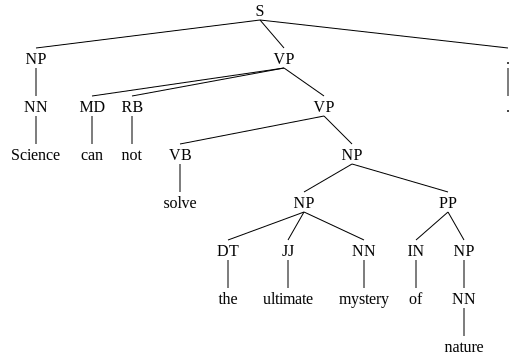

In [41]:
import nltk
benepar.download('benepar_en3')
nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('benepar', config={'model': 'benepar_en3'})
doc = nlp('Science cannot solve the ultimate mystery of nature.')
sent = list(doc.sents)[0]
print(sent._.parse_string)
print(sent._.labels)
print(list(sent._.children)[0])
nltk.Tree.fromstring(sent._.parse_string)

In the following, we show how to extract NSUBJ-verb pairs from text.

In [42]:
df = df.sample(n=200)
df["processed"] = df["snippet"].apply(lambda x: nlp(x)) # takes many time so we sample 200 data points

def extract_subject_verb_pairs(sent):
    subjs = [w for w in sent if w.dep_ == "nsubj"]
    pairs = [(w.lemma_.lower(), w.head.lemma_.lower()) for w in subjs]
    return pairs

df["subj-verb-pairs"] = df["processed"].apply(lambda x: extract_subject_verb_pairs(x))

In [43]:
# most common pairs
counter = Counter()
for item in df["subj-verb-pairs"]:
    counter.update(item)

for pair, counts in counter.most_common(n=25):
    print (pair, counts)

('penalty', 'be') 29
('state', 'seek') 13
('he', 'be') 9
('jury', 'find') 8
('defendant', 'be') 7
('he', 'vote') 6
('state', 'waive') 5
('this', 'be') 5
('it', 'be') 5
('she', 'be') 5
('he', 'have') 5
('statute', 'be') 5
('court', 'hold') 5
('jury', 'impose') 4
('she', 'vote') 4
('case', 'be') 4
('imposition', 'be') 4
('juror', 'be') 4
('record', 'reflect') 3
('he', 'say') 3
('petitioner', 'receive') 3
('defendant', 'assert') 3
('who', 'be') 3
('we', 'find') 3
('question', 'be') 3


In [44]:
# verbs used with defendant

for (subject, verb), counts in counter.most_common():
    if subject == "defendant" and counts > 1:
        print (subject, verb, counts)

defendant be 7
defendant assert 3
defendant guilty 3
defendant receive 2
defendant claim 2


In [45]:
# verbs used with jury

for (subject, verb), counts in counter.most_common():
    if subject == "jury" and counts > 1:
        print (subject, verb, counts)

jury find 8
jury impose 4
jury be 2
jury consider 2
